In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [4]:
df = pd.read_csv("/content/drive/MyDrive/internship/data/preprocessed_earthquake_data_v4.csv")

**Hypothesis 1: Magnitude Difference by Earthquake Type**

H0: Mean magnitude is equal across all earthquake types

H1: At least one type differs

In [5]:
# Group statistics
group_stats = df.groupby("type")["mag"].agg(["mean", "var", "count"])
print("Group Statistics:\n", group_stats)

# Extract groups for ANOVA
groups = [df[df["type"] == t]["mag"].dropna() for t in df["type"].unique()]

# ANOVA Test
f_stat, p_value = stats.f_oneway(*groups)
print("\nOne-Way ANOVA Results:")
print("F-statistic:", f_stat)
print("p-value:", p_value)

# If not normal → Kruskal-Wallis Test
h_stat, p_kw = stats.kruskal(*groups)
print("\nKruskal-Wallis H-test:")
print("H-statistic:", h_stat)
print("p-value:", p_kw)
if p_value < 0.05:
    print("Reject H0 → At least one earthquake type differs in magnitude.")
else:
    print("Fail to reject H0 → No significant difference.")


Group Statistics:
                        mean       var   count
type                                         
earthquake        -0.000736  1.001824  109356
explosion          0.310676  0.537291      10
landslide         -0.086071  0.000000       2
mine collapse     -0.545462       NaN       1
nuclear explosion  0.225033  0.609036     424
rock burst        -0.086071       NaN       1
volcanic eruption -0.318086  0.052105      54

One-Way ANOVA Results:
F-statistic: 4.714118175470631
p-value: 8.315527729182356e-05

Kruskal-Wallis H-test:
H-statistic: 76.11706048855315
p-value: 2.2598348801470093e-14
Reject H0 → At least one earthquake type differs in magnitude.


**Hypothesis 2: Damage Potential by Magnitude Category**


In [6]:
median_mag = df["mag"].median()
df["mag_category"] = np.where(df["mag"] >= median_mag, "High", "Low")

high = df[df["mag_category"] == "High"]["damage_potential"]
low = df[df["mag_category"] == "Low"]["damage_potential"]
# t-test
t_stat, p_t = stats.ttest_ind(high, low, nan_policy='omit')
print("\nT-Test:")
print("t-statistic:", t_stat)
print("p-value:", p_t)

# Mann-Whitney Test
u_stat, p_u = stats.mannwhitneyu(high, low, alternative='two-sided')
print("\nMann-Whitney U-Test:")
print("U-statistic:", u_stat)
print("p-value:", p_u)



T-Test:
t-statistic: -2.649099570934441
p-value: 0.008071809416725502

Mann-Whitney U-Test:
U-statistic: 1530101489.0
p-value: 3.9800253635632627e-16


**Hypothesis 3: Depth Impact on Magnitude**


Pearson Correlation:
Correlation: -0.010047995893078789
p-value: 0.0008675678827065724

Spearman Correlation:
Correlation: -0.049079606409161626
p-value: 1.4554852395513653e-59


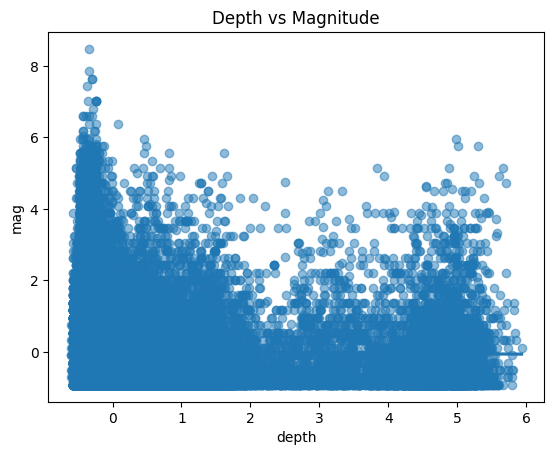

In [7]:
# Pearson
pearson_corr, p_pearson = stats.pearsonr(df["depth"], df["mag"])
print("\nPearson Correlation:")
print("Correlation:", pearson_corr)
print("p-value:", p_pearson)

# Spearman
spearman_corr, p_spearson = stats.spearmanr(df["depth"], df["mag"])
print("\nSpearman Correlation:")
print("Correlation:", spearman_corr)
print("p-value:", p_spearson)

# Scatter Plot
sns.regplot(x='depth', y='mag', data=df, scatter_kws={'alpha':0.5})
plt.title("Depth vs Magnitude")
plt.show()


**Hypothesis 4: Seasonal Earthquake Frequency**

month
1     8895
2     8196
3     9735
4     9134
5     9176
6     8814
7     9938
8     9644
9     8889
10    8991
11    8738
12    9698
Name: count, dtype: int64

Chi-Square Test
Chi-statistic: 312.3696744592528
p-value: 2.1623105984176013e-60


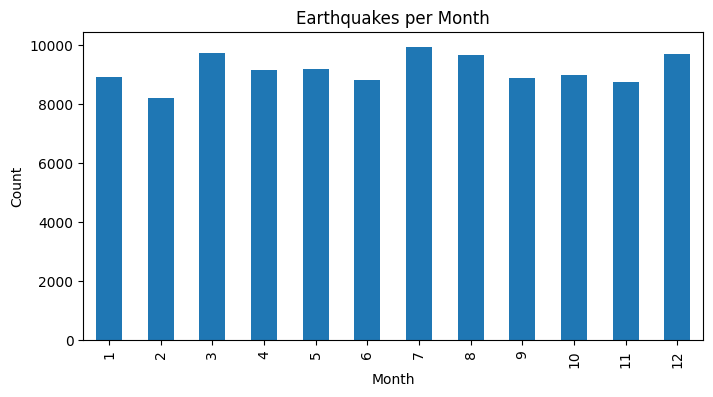

In [11]:
# build datetime column
df["datetime"] = pd.to_datetime(df[['Year','Month','Day','Hour','Minute','Second']])

# extract month
df["month"] = df["datetime"].dt.month

monthly_counts = df["month"].value_counts().sort_index()
print(monthly_counts)

# chi-square test (seasonality)
expected = [monthly_counts.mean()] * 12

chi_stat, p_chi = stats.chisquare(monthly_counts, f_exp=expected)

print("\nChi-Square Test")
print("Chi-statistic:", chi_stat)
print("p-value:", p_chi)

monthly_counts.plot(kind='bar', figsize=(8,4))
plt.title("Earthquakes per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()


**Hypothesis 5: RMS Variability by Magnitude**

In [10]:
# Group stats
print(df.groupby("magType")["rms"].agg(["mean", "count"]))

# Extract groups
groups_rms = [df[df["magType"] == t]["rms"].dropna() for t in df["magType"].unique()]

# ANOVA
f_rms, p_rms = stats.f_oneway(*groups_rms)
print("\nANOVA on RMS:")
print("F-statistic:", f_rms)
print("p-value:", p_rms)

# Levene’s Test (variance equality)
lev_stat, lev_p = stats.levene(*groups_rms)
print("\nLevene Test:")
print("Statistic:", lev_stat)
print("p-value:", lev_p)




                mean  count
magType                    
Mb         -0.101111      1
Md         -1.436125      1
Mi          1.213561     12
Ml         -1.722199      1
fa          0.008589      5
lg          0.066071      1
m          -0.100302     21
ma         -2.739353      1
mb         -0.034724  45084
mb_lg      -0.029520      1
mc         -2.035292      2
md         -2.187375     50
mh          7.881919     23
ml         -1.133615    485
ml(texnet) -2.389707      4
mlg        -2.453279      1
ms          0.258333   3157
ms_20       1.488192      3
mw          0.172614  24335
mwb         0.042883   3082
mwc         0.126692  17458
mwp        -1.972956      9
mwr        -0.129691    451
mww        -0.334510  15652
uk          0.046273      8

ANOVA on RMS:
F-statistic: 238.22142131224834
p-value: 0.0

Levene Test:
Statistic: 217.9064249747279
p-value: 0.0
